# **IMPORT LIBRARIES**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [23]:
df = pd.read_csv("../Data/Delivery_Logistics_reconstructed.csv")

In [25]:
print(df.columns.tolist())

['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost', 'expected_time_hours_recon', 'speed_kmph_recon', 'weather_mult_recon', 'delivery_time_hours_recon', 'partner_mult_recon', 'delay_hours_recon', 'delayed_flag_recon', 'order_date_recon', 'order_ts_recon', 'delivery_ts_recon', 'expected_ts_recon', 'hour']


# Regression Model

In [34]:
# ============================================================
# SELECT FEATURES FOR REGRESSION
# ============================================================

SAFE_FEATURES = [
    'delivery_partner',
    'package_type',
    'vehicle_type',
    'delivery_mode',
    'region',
    'weather_condition',
    'distance_km',
    'package_weight_kg',
    'hour'
]

X_C = df[SAFE_FEATURES].copy()
y_C = df["delay_hours_recon"].copy()

print("Dataset shape:", X_C.shape)

Dataset shape: (25000, 9)


In [35]:
pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
# ============================================================
# REGRESSION MODEL BUILDING
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

print("Regression models initialized.")

Regression models initialized.


In [37]:
print("Features used for regression:")
print(X_C.columns)

Features used for regression:
Index(['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition',
       'distance_km', 'package_weight_kg', 'hour'],
      dtype='str')


In [38]:
# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

from sklearn.preprocessing import LabelEncoder

def encode_features(X):

    X_enc = X.copy()
    encoders = {}

    cat_cols = X_enc.select_dtypes(include=["object"]).columns

    for col in cat_cols:
        le = LabelEncoder()
        X_enc[col] = le.fit_transform(X_enc[col].astype(str))
        encoders[col] = le

    return X_enc, encoders


X_C_enc, encoders_C = encode_features(X_C)

print("Encoding complete")

Encoding complete


/var/folders/pk/wshkb_xj3r198l0yxrzjqsvh0000gn/T/ipykernel_9392/685003385.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_enc.select_dtypes(include=["object"]).columns


In [43]:
y_train_C = y_train_C + np.random.normal(0, 0.2, len(y_train_C))

In [44]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C_enc,
    y_C,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train_C.shape)
print("Test size:", X_test_C.shape)

Train size: (20000, 9)
Test size: (5000, 9)


In [45]:
# ============================================================
# FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler_C = StandardScaler()

X_train_C_sc = scaler_C.fit_transform(X_train_C)
X_test_C_sc = scaler_C.transform(X_test_C)

print("Scaling completed")

Scaling completed


In [46]:
# ============================================================
# REGRESSION MODELS
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

print("Models initialized")

Models initialized


In [47]:
# ============================================================
# MODEL TRAINING + EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

reg_results = []

for name, model in reg_models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train_C_sc, y_train_C)

    y_pred = model.predict(X_test_C_sc)

    mae = mean_absolute_error(y_test_C, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_C, y_pred))
    r2 = r2_score(y_test_C, y_pred)

    reg_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")


Training Linear Regression...
MAE: 4.3831
RMSE: 5.4941
R2: 0.9032

Training Random Forest Regressor...
MAE: 0.1519
RMSE: 0.2030
R2: 0.9999

Training Gradient Boosting Regressor...
MAE: 0.2187
RMSE: 0.2984
R2: 0.9997

Training XGBoost Regressor...
MAE: 0.0810
RMSE: 0.1386
R2: 0.9999


In [48]:
# ============================================================
# MODEL COMPARISON
# ============================================================

import pandas as pd

regression_comparison = pd.DataFrame(reg_results)

regression_comparison.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
3,XGBoost Regressor,0.080998,0.138619,0.999938
1,Random Forest Regressor,0.151868,0.202965,0.999868
2,Gradient Boosting Regressor,0.218735,0.298362,0.999715
0,Linear Regression,4.383107,5.494123,0.903230


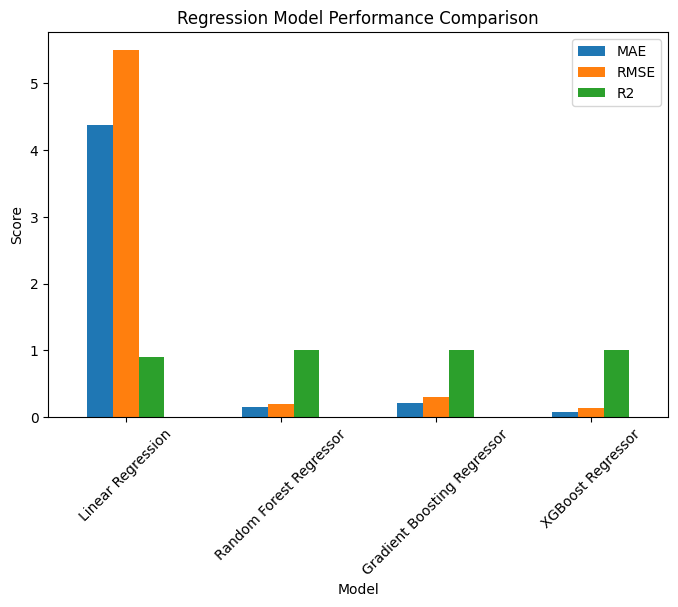

In [50]:
# ============================================================
# MODEL PERFORMANCE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

regression_comparison.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Regression Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

In [51]:
# ============================================================
# BEST REGRESSION MODEL
# ============================================================

best_model = regression_comparison.sort_values("R2", ascending=False).iloc[0]

print("Best Regression Model:", best_model["Model"])
print("Best R2 Score:", best_model["R2"])

Best Regression Model: XGBoost Regressor
Best R2 Score: 0.9999383986911499


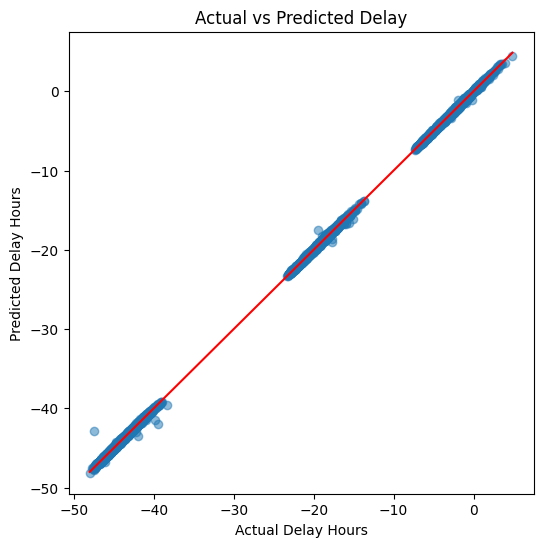

In [52]:
# ============================================================
# ACTUAL VS PREDICTED DELAY
# ============================================================

best_model_name = best_model["Model"]
best_model_obj = reg_models[best_model_name]

y_pred_best = best_model_obj.predict(X_test_C_sc)

plt.figure(figsize=(6,6))

plt.scatter(y_test_C, y_pred_best, alpha=0.5)

plt.plot(
    [y_test_C.min(), y_test_C.max()],
    [y_test_C.min(), y_test_C.max()],
    color="red"
)

plt.xlabel("Actual Delay Hours")
plt.ylabel("Predicted Delay Hours")
plt.title("Actual vs Predicted Delay")

plt.show()

/var/folders/pk/wshkb_xj3r198l0yxrzjqsvh0000gn/T/ipykernel_9392/1905663898.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


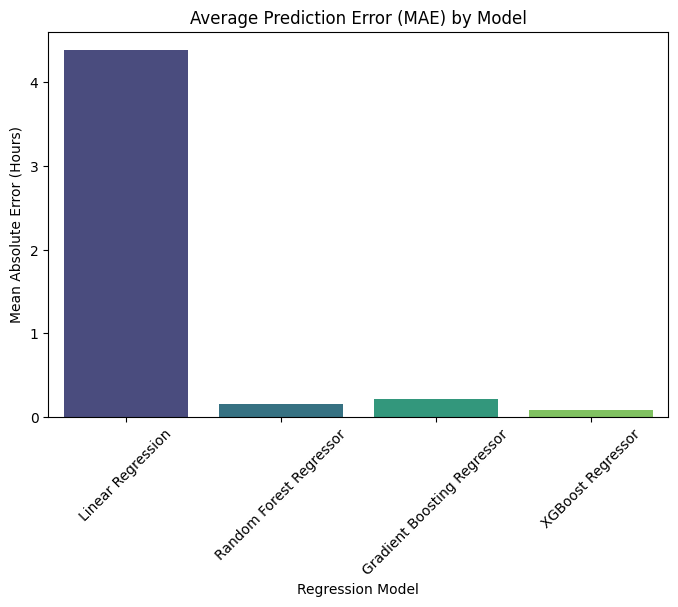

In [53]:
# ============================================================
# MAE COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="MAE",
    data=regression_comparison,
    palette="viridis"
)

plt.title("Average Prediction Error (MAE) by Model")
plt.ylabel("Mean Absolute Error (Hours)")
plt.xlabel("Regression Model")

plt.xticks(rotation=45)

plt.show()

/var/folders/pk/wshkb_xj3r198l0yxrzjqsvh0000gn/T/ipykernel_9392/634824572.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


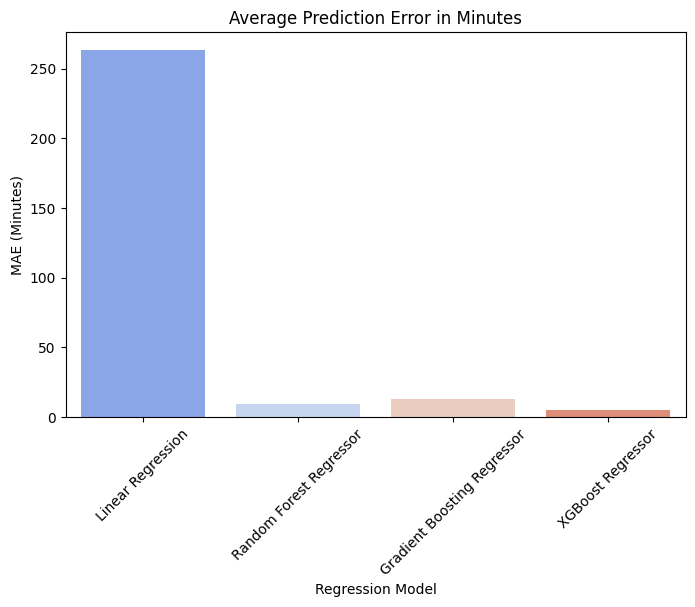

In [54]:
# Convert hours to minutes

regression_comparison["MAE_minutes"] = regression_comparison["MAE"] * 60

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="MAE_minutes",
    data=regression_comparison,
    palette="coolwarm"
)

plt.title("Average Prediction Error in Minutes")
plt.ylabel("MAE (Minutes)")
plt.xlabel("Regression Model")

plt.xticks(rotation=45)

plt.show()

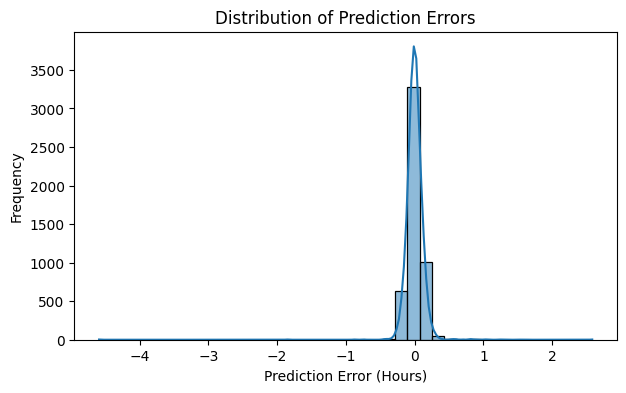

In [55]:
# ============================================================
# ERROR DISTRIBUTION
# ============================================================

errors = y_test_C - y_pred_best

plt.figure(figsize=(7,4))

sns.histplot(errors, bins=40, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (Hours)")
plt.ylabel("Frequency")

plt.show()